# 2 — The relaxation and graining tire cell

Two dynamic extensions, both encoded rather than learned:

* **Relaxation (P5)** — $\dot F = (F_{ss}-F)/\tau$ with $\tau = \sigma/(|v_x|+\varepsilon)$.
  The transient is parameterised by *travelled distance*, not time.
* **Thermal / wear / graining (P7)** — latent state $[T_s, T_c, w, g]$ where wear is
  irreversible and graining is confined to $[0,1]$ **by construction**.

The graining part is a **synthetic, weakly supervised demonstrator**. It shows that the
structure can represent and identify these effects. It is not validated real motorsport
graining.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": 0.3})
from tire_nn.training import set_seed
set_seed(0)

/home/poxx/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. Why $\tau = \sigma/v$ and not a learned time constant

The same model, the same slip step, three speeds — plotted against time and against
travelled distance.

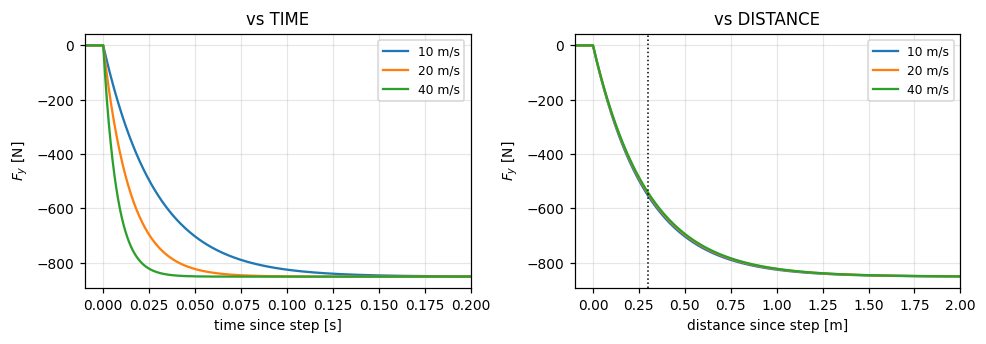

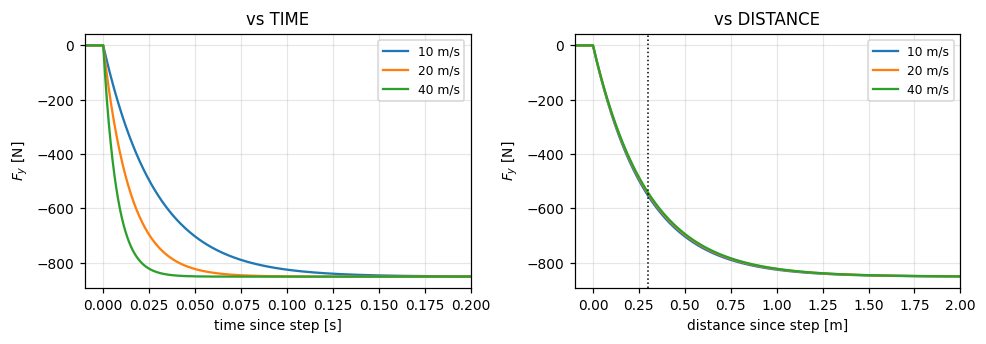

In [2]:
from tire_nn.models.relaxation_tire import RelaxationTireCell
from tire_nn.physics import MagicFormulaTire, MFParams

cell = RelaxationTireCell(MagicFormulaTire(MFParams(mu=1.0), MFParams(mu=1.0)))
with torch.no_grad():
    cell.sigma_y.raw.fill_(float(cell.sigma_y.spec.inverse(0.30)))
    cell.sigma_x.raw.fill_(float(cell.sigma_x.spec.inverse(0.15)))

dt, T, step = 5e-4, 3000, 200
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
for vx in (10.0, 20.0, 40.0):
    a = torch.zeros(1, T); a[:, step:] = 0.08
    z = torch.zeros(1, T); Fz = torch.full((1, T), 1000.0); v = torch.full((1, T), vx)
    F = cell.rollout(a, z, Fz, v, dt, {"vx": v}, method="exact").detach()
    t = (np.arange(T) - step) * dt
    axes[0].plot(t, F[0, :, 1], label=f"{vx:.0f} m/s")
    axes[1].plot(t * vx, F[0, :, 1], label=f"{vx:.0f} m/s")
axes[0].set_xlim(-0.01, 0.2); axes[0].set_xlabel("time since step [s]"); axes[0].set_title("vs TIME")
axes[1].set_xlim(-0.1, 2.0); axes[1].set_xlabel("distance since step [m]"); axes[1].set_title("vs DISTANCE")
axes[1].axvline(0.30, color="k", ls=":", lw=1)
for ax in axes:
    ax.set_ylabel("$F_y$ [N]"); ax.legend(fontsize=8)
fig.tight_layout(); fig

The curves collapse on the distance axis, and the 63 % point is the relaxation
length. A generic recurrent model has to *learn* that collapse from data.

## 2. Identifying the relaxation length from step tests

Synthetic step sequences with known $\sigma_x=0.15$, $\sigma_y=0.30$ m, and — crucially
— a different constant speed per sequence.

In [3]:
from tire_nn.data import make_synthetic_transient, TireDataset, split_by_group
from tire_nn.models import EncodedTireNet
from tire_nn.training import TrainConfig, train_model

TRUE_SX, TRUE_SY = 0.15, 0.30
df = make_synthetic_transient(n_sequences=24, T=300, dt=0.002,
                              sigma_x=TRUE_SX, sigma_y=TRUE_SY,
                              vx_range=(5.0, 35.0), vary_mu=True, noise=0.005, seed=1)
tr, va, te = split_by_group(df, seed=0)
mk = lambda d: TireDataset(d, targets=("Fx", "Fy"), context_keys=("vx",), window=60)
print(f"{df['sequence_id'].nunique()} sequences, speeds "
      f"{df.groupby('sequence_id')['vx'].first().min():.1f}-"
      f"{df.groupby('sequence_id')['vx'].first().max():.1f} m/s")

24 sequences, speeds 5.6-29.4 m/s


In [4]:
from tire_nn.models.baselines_seq import GRUTireModel, NeuralODETireModel

cfg = dict(epochs=12, batch_size=128, lr=8e-3, patience=6,
           mode="sequence", dt=0.002, integrator="rk4", targets=("Fx", "Fy"))

candidates = {
    "static":       EncodedTireNet(context_keys=("vx",)),
    "gru":          GRUTireModel(context_keys=("vx",)),
    "neural_ode":   NeuralODETireModel(context_keys=("vx",)),
    "relaxation":   RelaxationTireCell(EncodedTireNet(context_keys=("vx",))),
}
for name, m in candidates.items():
    train_model(m, mk(tr), mk(va), TrainConfig(**cfg), verbose=False)
    m.eval()
    print(f"{name:12s} done  ({sum(p.numel() for p in m.parameters()):5d} params)")

sig_x, sig_y = float(candidates["relaxation"].sigma_x()), float(candidates["relaxation"].sigma_y())
print(f"\nrecovered sigma_x = {sig_x:.3f} m (true {TRUE_SX})")
print(f"recovered sigma_y = {sig_y:.3f} m (true {TRUE_SY})")

static       done  ( 1323 params)


gru          done  ( 3907 params)


neural_ode   done  ( 1411 params)


relaxation   done  ( 1325 params)

recovered sigma_x = 0.122 m (true 0.15)
recovered sigma_y = 0.253 m (true 0.3)


/tmp/ipykernel_167943/2617174635.py:17: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:822.)
  sig_x, sig_y = float(candidates["relaxation"].sigma_x()), float(candidates["relaxation"].sigma_y())


## 3. The decisive diagnostic: rise distance vs speed

Distance travelled to reach 63 % of a slip step, measured at two speeds. A ratio near
**1** means the transient is parameterised by distance (physically correct); a ratio
near **3** means a fixed *time* constant was learned.

In [5]:
@torch.no_grad()
def rise_distance(model, vx, dt=0.002, T=400):
    a = torch.zeros(1, T); a[:, T // 4:] = 0.1
    z = torch.zeros(1, T); Fz = torch.full((1, T), 1000.0); v = torch.full((1, T), vx)
    Fy = model.rollout(a, z, Fz, v, dt, {"vx": v}, method="rk4")[0, :, 1]
    start, final = Fy[T // 4 - 1], Fy[-1]
    target = start + 0.632 * (final - start)
    reached = (Fy[T // 4:] - start).abs() >= (target - start).abs()
    idx = int(torch.nonzero(reached)[0]) if reached.any() else T
    return idx * dt * vx

from tire_nn.training.metrics import rmse

rows = []
for name, m in candidates.items():
    d10, d30 = rise_distance(m, 10.0), rise_distance(m, 30.0)
    errs = []
    for _, g in te.groupby("sequence_id"):
        t = lambda c: torch.as_tensor(g[c].to_numpy(), dtype=torch.float32).unsqueeze(0)
        F = m.rollout(t("alpha"), t("kappa"), t("Fz"), t("vx"), 0.002, {"vx": t("vx")}, method="rk4")
        errs.append(rmse(F[0, :, 1], t("Fy")[0]))
    rows.append({"model": name, "Fy_rollout_rmse": float(np.mean(errs)),
                 "rise_dist_10ms": d10, "rise_dist_30ms": d30,
                 "ratio": d30 / max(d10, 1e-9)})
pd.DataFrame(rows).round(3)

,model,Fy_rollout_rmse,rise_dist_10ms,rise_dist_30ms,ratio
0,static,293.046,0.00,0.00,0.000
1,gru,203.077,0.34,0.18,0.529
2,neural_ode,252.039,0.14,0.42,3.000
3,relaxation,109.758,0.26,0.30,1.154


## 4. Thermal, wear and graining

A four-phase synthetic stint: cold and aggressive, hot and aggressive, cool-down, then
aggressive again. Watch graining form on the cold surface, clean up as it warms, and
wear accumulate monotonically throughout.

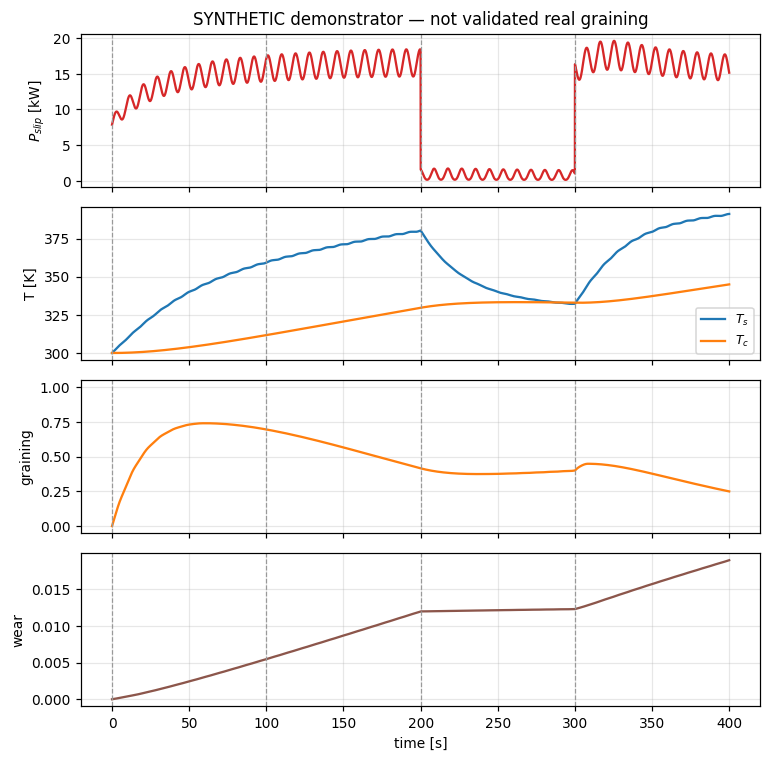

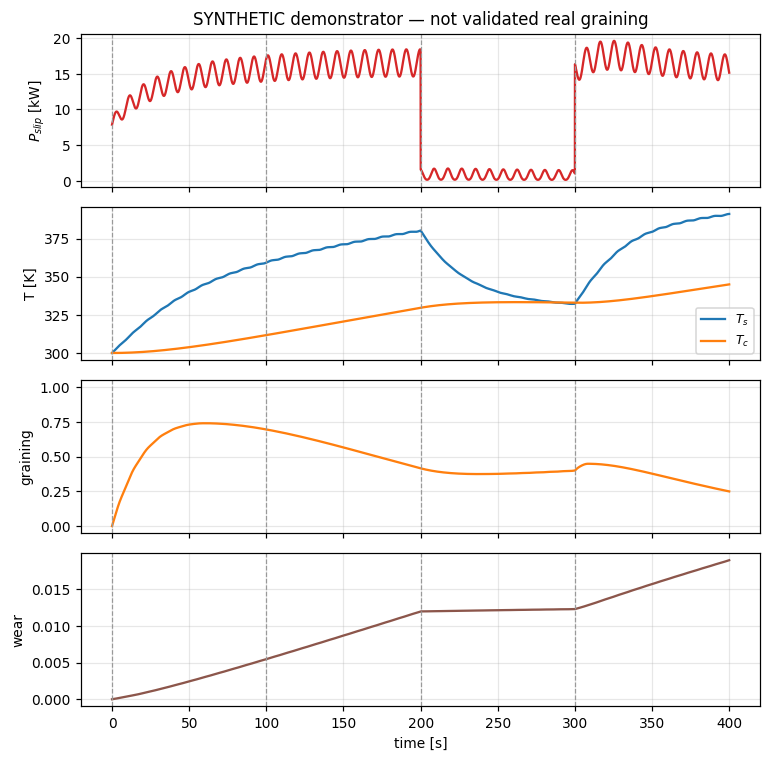

In [6]:
from tire_nn.data.graining import make_synthetic_graining

stint = make_synthetic_graining(T=8000, dt=0.05, noise_state=1.0, seed=0)
t = stint["t"].to_numpy()
fig, axes = plt.subplots(4, 1, figsize=(7, 7), sharex=True)
axes[0].plot(t, stint["P_slip"] / 1000, color="tab:red"); axes[0].set_ylabel("$P_{slip}$ [kW]")
axes[1].plot(t, stint["Ts"], label="$T_s$"); axes[1].plot(t, stint["Tc"], label="$T_c$")
axes[1].set_ylabel("T [K]"); axes[1].legend(fontsize=8)
axes[2].plot(t, stint["graining"], color="tab:orange"); axes[2].set_ylabel("graining"); axes[2].set_ylim(-0.05, 1.05)
axes[3].plot(t, stint["wear"], color="tab:brown"); axes[3].set_ylabel("wear"); axes[3].set_xlabel("time [s]")
for i in range(4):
    for ax in axes: ax.axvline(t[len(t)//4*i], color="0.6", lw=0.8, ls="--")
axes[0].set_title("SYNTHETIC demonstrator — not validated real graining")
fig.tight_layout(); fig

## 5. The structural guarantees

Wear irreversibility and $g\in[0,1]$ hold for **arbitrary** weights and an
adversarially coarse step size — they are properties of the equations, not of training.

In [7]:
from tire_nn.models.thermo_graining_tire import ThermoGrainingTire

model = ThermoGrainingTire(EncodedTireNet(context_keys=("vx",)))
with torch.no_grad():                      # deliberately absurd weights
    for p in model.parameters():
        p.normal_(0.0, 20.0)

ones = torch.ones(1, 2000)
_, z, extra = model.rollout_condition(ones * 0.12, ones * 0.05, ones * 3000.0, ones * 40.0,
                                      dt=0.5)     # dt 10x larger than anything sane
wear, g = z[0, :, 2].detach(), z[0, :, 3].detach()
print(f"wear monotone non-decreasing : {bool((torch.diff(wear) >= -1e-12).all())}")
print(f"graining in [0, 1]           : {float(g.min()):.4f} .. {float(g.max()):.4f}")
print(f"slip power non-negative      : {float(extra['P_slip'].min()) >= 0}")
print(f"temperatures finite          : {bool(torch.isfinite(z[..., :2]).all())}")

wear monotone non-decreasing : True
graining in [0, 1]           : 0.0000 .. 0.1789
slip power non-negative      : True
temperatures finite          : True


## 6. Training the condition model on weak labels

Only noisy $T_s$ and $g$ observations plus the force — no rate is ever observed.

In [8]:
model = ThermoGrainingTire(EncodedTireNet(context_keys=("vx",)))
opt = torch.optim.Adam(model.parameters(), lr=5e-3)
dt, W = 0.05, 400
chunks = [stint.iloc[i:i+W] for i in range(0, len(stint) - W + 1, W)]
tt = lambda c, ch: torch.as_tensor(ch[c].to_numpy(), dtype=torch.float32).unsqueeze(0)

hist = []
for epoch in range(8):
    total = 0.0
    for ch in chunks:
        opt.zero_grad(set_to_none=True)
        F, z, _ = model.rollout_condition(
            tt("alpha", ch), tt("kappa", ch), tt("Fz", ch), tt("vx", ch), dt,
            T_road=float(ch["T_road"].iloc[0]), T_air=float(ch["T_air"].iloc[0]),
            z0=torch.tensor([[float(ch["Ts"].iloc[0]), float(ch["Tc"].iloc[0]),
                              float(ch["wear"].iloc[0]), float(ch["graining"].iloc[0])]]))
        loss = (((F[..., 0] - tt("Fx", ch))**2 + (F[..., 1] - tt("Fy", ch))**2).mean() / 3000**2
                + 0.5 * ((z[..., 0] - tt("Ts_meas", ch))**2).mean() / 100
                + 0.5 * ((z[..., 3] - tt("graining_meas", ch))**2).mean())
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 10.0)
        opt.step()
        total += float(loss.detach())
    hist.append(total / len(chunks))
print(f"loss {hist[0]:.4f} -> {hist[-1]:.4f}")
print(f"learned T_opt = {float(model.T_opt()):.1f} K   k_grain = {float(model.k_grain()):.3f}   "
      f"k_wear = {float(model.k_wear()):.3f}")

loss 0.1826 -> 0.1418
learned T_opt = 360.8 K   k_grain = 0.274   k_wear = 0.075


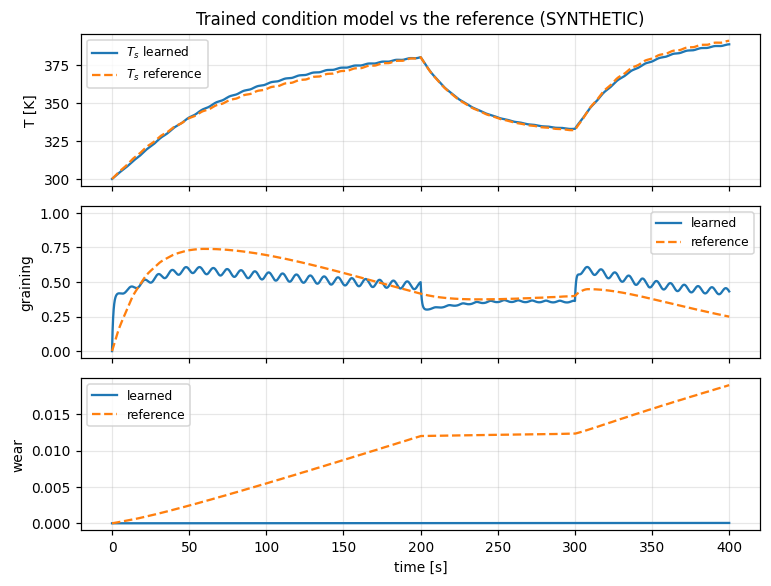

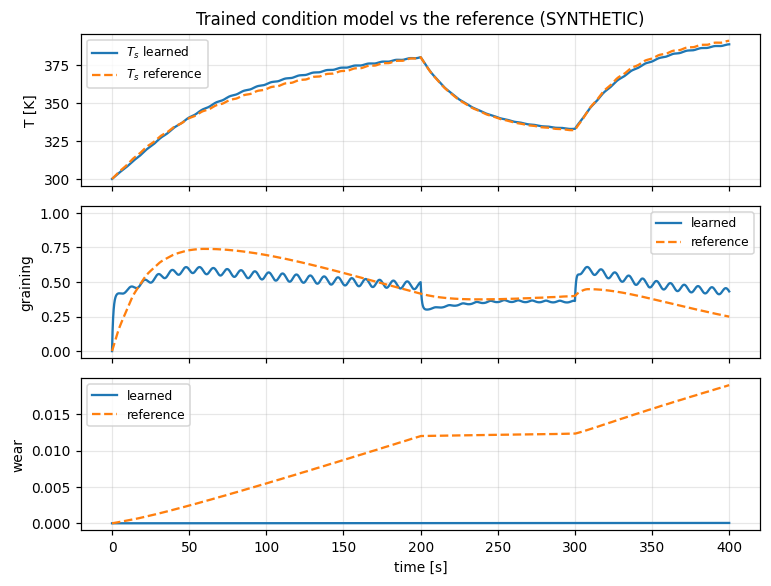

In [9]:
model.eval()
with torch.no_grad():
    F, z, ex = model.rollout_condition(
        tt("alpha", stint), tt("kappa", stint), tt("Fz", stint), tt("vx", stint), dt,
        T_road=float(stint["T_road"].iloc[0]), T_air=float(stint["T_air"].iloc[0]))

fig, axes = plt.subplots(3, 1, figsize=(7, 5.4), sharex=True)
axes[0].plot(t, z[0, :, 0], label="$T_s$ learned"); axes[0].plot(t, stint["Ts"], "--", label="$T_s$ reference")
axes[0].set_ylabel("T [K]"); axes[0].legend(fontsize=8)
axes[1].plot(t, z[0, :, 3], label="learned"); axes[1].plot(t, stint["graining"], "--", label="reference")
axes[1].set_ylabel("graining"); axes[1].set_ylim(-0.05, 1.05); axes[1].legend(fontsize=8)
axes[2].plot(t, z[0, :, 2], label="learned"); axes[2].plot(t, stint["wear"], "--", label="reference")
axes[2].set_ylabel("wear"); axes[2].set_xlabel("time [s]"); axes[2].legend(fontsize=8)
axes[0].set_title("Trained condition model vs the reference (SYNTHETIC)")
fig.tight_layout(); fig

## Takeaways

1. Encoding $\tau=\sigma/v$ makes the transient speed-invariant *by construction* and
   turns the learned quantity into a length an engineer can check against a rig. Here it
   recovered $\sigma_y \approx 0.25$ m against a true 0.30 m from 12 epochs of step tests.
2. The encoded cell also has the lowest rollout error — roughly half the GRU's.
3. **The unstructured baselines have no consistent speed law.** The Neural ODE's rise
   distance scales with speed (ratio 3.0 — a fixed *time* constant), while the GRU's ratio
   came out at 0.53 in this run and above 2 in the Experiment 2 script run. That is the
   point: without the structure, whatever speed dependence the model ends up with is a
   property of the run, not of the tire. Only the encoded cell is reliably near 1.
4. Wear irreversibility and $g\in[0,1]$ survive absurd weights and an absurd step size,
   because they are properties of the equations, not of training.
5. **The graining results are synthetic, and this fit is short.** Eight epochs of weak
   supervision underfits the formation rate — the learned graining peaks well below the
   reference. The notebook demonstrates that the structure is trainable and that its
   guarantees hold; it says nothing about a real tire.